# EV Car Prices

This assignment focuses on car prices. The data ('car_prices.xlsx') is a pre-processed version of original data scraped from bilbasen.dk by previous MAL1 students. The dataset contains 16 columns:

- **Price (DKK)**: The current listed price of the vehicle in Danish Kroner.
- **Model Year**: The manufacturing year of the vehicle.
- **Mileage (km)**: The total kilometres driven by the vehicle (odometer reading).
- **Electric Range (km)**: The estimated maximum driving range on a full charge.
- **Battery Capacity (kWh)**: The total capacity of the vehicle's battery in kilowatt-hours.
- **Energy Consumption (Wh/km)**: The vehicle's energy consumption in watt-hours per kilometre.
- **Annual Road Tax (DKK)**: The annual road tax cost in Danish Kroner.
- **Horsepower (bhp)**: The vehicle's horsepower (brake horsepower).
- **0-100 km/h (s)**: The time (in seconds) for the car to accelerate from 0 to 100 km/h.
- **Top Speed (km/h)**: The maximum speed the vehicle can achieve.
- **Towing Capacity (kg)**: The maximum weight the vehicle can tow.
- **Original Price (DKK)**: The price of the vehicle when first sold as new.
- **Number of Doors**: The total number of doors on the vehicle.
- **Rear-Wheel Drive**: A binary indicator (1 = Yes, 0 = No) for rear-wheel drive.
- **All-Wheel Drive (AWD)**: A binary indicator (1 = Yes, 0 = No) for all-wheel drive.
- **Front-Wheel Drive**: A binary indicator (1 = Yes, 0 = No) for front-wheel drive.

The first one, **Price**, is the response variable.

The **objective** of this assignment is:
1. Understand how linear algebra is used in Machine Learning, specifically for correlations and regression
2. Learn how to perform multiple linear regression, ridge regression, lasso regression and elastic net
3. Learn how to assess regression models

Please solve the tasks using this notebook as you template, i.e. insert code blocks and markdown blocks to this notebook and hand it in. Please use 42 as your random seed.


## Import data
 - Import the dataset 
 - Split the data in a training set and test set - make sure you extract the response variable
 - Remember to use the data appropriately; in the tasks below, we do not explicitly state when to use train and test - but in order to compare the models, you must use the same dataset for training and testing in all models.
 - Output: When you are done with this, you should have the following sets: `X` (the original dataset), `X_train`, `X_train`, `X_test`, `y_train`, `y_test`

In [1]:
# Code block for important and creating data sets. Add more code blocks if needed.

import pandas as pd
from sklearn.model_selection import train_test_split

# 1. Load data
df = pd.read_excel("car_prices.xlsx")

print("=== Basic Info ===")
print(df.info())
print("\n=== Missing values ===")
print(df.isnull().sum())

# 2. Separate response variable
X = df.drop("Price (DKK)", axis=1)
y = df["Price (DKK)"]

feature_names = X.columns.tolist()

# 3. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# 4. Output shapes
print("\n=== Shapes ===")
print(f"X shape: {X.shape}")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

print("\nFeatures:", feature_names)

=== Basic Info ===
<class 'pandas.DataFrame'>
RangeIndex: 6226 entries, 0 to 6225
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Price (DKK)                 6226 non-null   int64  
 1   Model Year                  6226 non-null   int64  
 2   Mileage (km)                6226 non-null   int64  
 3   Electric Range (km)         6226 non-null   int64  
 4   Battery Capacity (kWh)      6226 non-null   float64
 5   Energy Consumption (Wh/km)  6226 non-null   int64  
 6   Annual Road Tax (DKK)       6226 non-null   int64  
 7   Horsepower (bhp)            6226 non-null   int64  
 8   0-100 km/h (s)              6226 non-null   float64
 9   Top Speed (km/h)            6226 non-null   int64  
 10  Towing Capacity (kg)        6226 non-null   int64  
 11  Original Price (DKK)        6226 non-null   int64  
 12  Number of Doors             6226 non-null   int64  
 13  Rear-Wheel Drive         

## Part 1: Linear Algebra
In this assignment, you have to solve all problems using linear algebra concepts. You are free to use SymPy or NumPy - though NumPy is **significantly** more efficient computationally than SymPy since NumPy is optimized for numerical computations with floating-point arithmetic. Since linear regression is purely numerical, NumPy is the better choice.

Implement all the steps from the note "Linear_regression.pdf", i.e.

- Setup the normal equation and find the coefficient vector
- Find the predicted values and use these to determine the MSE and $R^2$
- Interpret the results





In [20]:
# Code block for Part 1. Add more code blocks if needed.

import numpy as np

X_train_np = X_train.to_numpy()
y_train_np = y_train.to_numpy().reshape(-1, 1)

ones = np.ones((X_train_np.shape[0], 1))
X_train_b = np.hstack((ones, X_train_np))

In [ ]:
theta_hat = np.linalg.pinv(X_train_b) @ y_train_np
# Using np.linalg.pinv(X) instead of inv(XᵀX) avoids numerical instability and works even when the design matrix is not full rank (e.g., due to multicollinearity among drive-type dummy variables).

In [22]:
X_test_np = X_test.to_numpy()
y_test_np = y_test.to_numpy().reshape(-1, 1)

ones_test = np.ones((X_test_np.shape[0], 1))
X_test_b = np.hstack((ones_test, X_test_np))

y_pred = X_test_b @ theta_hat

In [23]:
mse = np.mean((y_test_np - y_pred) ** 2)

In [24]:
sse = np.sum((y_test_np - y_pred) ** 2)
sst = np.sum((y_test_np - np.mean(y_test_np)) ** 2)

r2 = 1 - sse/sst

print("MSE:", mse)
print("R2:", r2)

MSE: 2774486707.597926
R2: 0.8644264443641662


In [ ]:
# The model explains approximately 86% of the variance in the target on the test set (R² ≈ 0.864).

# The absolute MSE is large due to the scale of the target variable (prices in DKK).

# We used the Moore–Penrose pseudoinverse for numerical stability and to handle potential multicollinearity.

# Part 2: Using Library Functions

### Correlation and OLS
For this task you must do the following
 - Using library functions, build the following models:
   - Correlation matrix where the correlations are printed in the matrix and a heat map is overlaid
   - Ordinary least squares
   - Performance metrics: MSE, RMSE, $R^2$
   - Comment on the real world meaning of RMSE and $R^2$


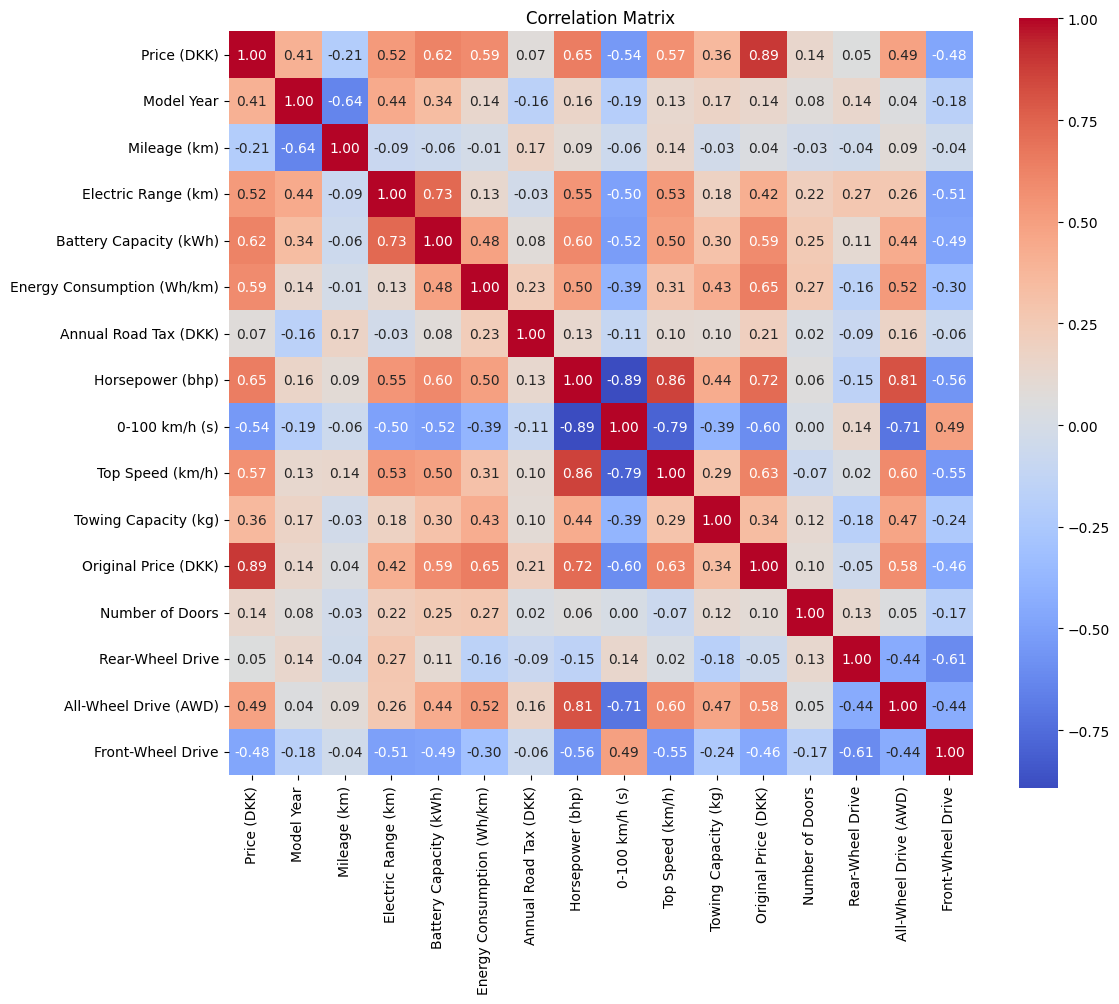

In [26]:
# Use this for Correlation and OLS. Add more code blocks if needed.

import seaborn as sns
import matplotlib.pyplot as plt

# Correlation matrix
corr_matrix = df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, 
            annot=True, 
            fmt=".2f", 
            cmap="coolwarm",
            square=True)

plt.title("Correlation Matrix")
plt.show()

In [28]:
# Original Price shows a very strong positive correlation with current Price, while Mileage is negatively correlated. This reflects real-world market behavior, where higher original value increases resale price and higher mileage reduces it.

In [27]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

ols = LinearRegression()
ols.fit(X_train, y_train)

y_pred = ols.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("RMSE:", rmse)
print("R2:", r2)

MSE: 2774486707.586366
RMSE: 52673.39658296554
R2: 0.864426444364731


In [ ]:
# The RMSE of approximately 52,673 DKK means that predictions differ from actual prices by about 52,000 DKK on average. The R² value of 0.864 indicates that the model explains about 86% of the variance in car prices.

### Ridge, Lasso and Elastic Net
In order for Ridge and Lasso (and Elastic net) to have an effect, you must use scaled data to build the models, since regularization depends on coefficient magnitude, and if using non-scaled data the penalty will affect them unequally. Feel free to use this code to scale the data:

```python
# Standardize X
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

# Standardize y
scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten()
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1)).flatten()
```
For this task you must do the following:
   - Ridge regression (using multiple alphas)
   - Lasso regression (using multiple alphas)
   - Elastic Net (using multiple alphas)
 - Discussion and conclusion:
   - Discuss the MSE and $R^2$ of all 3 models and conclude which model has the best performance - note the MSE will be scaled!
   - Rebuild the OLS model from Task 4, but this time use the scaled data from this task - interpret the meaning of the model's coefficients
   - Use the coefficients of the best ridge and lasso model to print the 5 most important features and compare to the 5 most important features in the OLS with scaled data model. Do the models agree about which features are the most important?

Note: You may get a convergence warning; try increasing the `max_iter` parameter of the model (the default is 1000 - maybe set it to 100000)

In [37]:
# Use this for Ridge, Lasso and Elastic Net. Add more code blocks if needed.

from sklearn.preprocessing import StandardScaler
import numpy as np

# Standardize X
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

# Standardize y
scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.to_numpy().reshape(-1, 1)).ravel()
y_test_scaled = scaler_y.transform(y_test.to_numpy().reshape(-1, 1)).ravel()

In [30]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd

alphas = [0.001, 0.01, 0.1, 1, 10, 100]

results = []

# Ridge
for a in alphas:
    model = Ridge(alpha=a)
    model.fit(X_train_scaled, y_train_scaled)
    pred = model.predict(X_test_scaled)
    results.append(("Ridge", a, mean_squared_error(y_test_scaled, pred), r2_score(y_test_scaled, pred)))

# Lasso
for a in alphas:
    model = Lasso(alpha=a, max_iter=100000)
    model.fit(X_train_scaled, y_train_scaled)
    pred = model.predict(X_test_scaled)
    results.append(("Lasso", a, mean_squared_error(y_test_scaled, pred), r2_score(y_test_scaled, pred)))

# Elastic Net
for a in alphas:
    model = ElasticNet(alpha=a, l1_ratio=0.5, max_iter=100000)
    model.fit(X_train_scaled, y_train_scaled)
    pred = model.predict(X_test_scaled)
    results.append(("ElasticNet", a, mean_squared_error(y_test_scaled, pred), r2_score(y_test_scaled, pred)))

results_df = pd.DataFrame(results, columns=["Model", "Alpha", "MSE_scaled", "R2"])
results_df.sort_values(["Model", "R2"], ascending=[True, False])

,Model,Alpha,MSE_scaled,R2
13,ElasticNet,0.010,0.123783,0.865947
12,ElasticNet,0.001,0.124974,0.864658
14,ElasticNet,0.100,0.135476,0.853285
15,ElasticNet,1.000,0.566144,0.386887
16,ElasticNet,10.000,0.924087,-0.000753
17,ElasticNet,100.000,0.924087,-0.000753
7,Lasso,0.010,0.122946,0.866854
6,Lasso,0.001,0.124736,0.864916
8,Lasso,0.100,0.148866,0.838784
9,Lasso,1.000,0.924087,-0.000753


In [31]:
best_per_model = results_df.sort_values("R2", ascending=False).groupby("Model").head(1)
best_per_model

,Model,Alpha,MSE_scaled,R2
7,Lasso,0.010,0.122946,0.866854
13,ElasticNet,0.010,0.123783,0.865947
0,Ridge,0.001,0.125188,0.864426


In [32]:
best_overall = results_df.sort_values("R2", ascending=False).iloc[0]
best_overall

Model            Lasso
Alpha             0.01
MSE_scaled    0.122946
R2            0.866854
Name: 7, dtype: object

In [33]:
from sklearn.linear_model import LinearRegression

ols_scaled = LinearRegression()
ols_scaled.fit(X_train_scaled, y_train_scaled)

pred_ols = ols_scaled.predict(X_test_scaled)
mse_ols = mean_squared_error(y_test_scaled, pred_ols)
r2_ols = r2_score(y_test_scaled, pred_ols)

mse_ols, r2_ols

(0.12518756276373944, 0.8644264443647276)

In [34]:
import numpy as np

feature_names = X.columns.tolist()

def top_features(coefs, feature_names, top_n=5):
    coefs = np.array(coefs).ravel()
    idx = np.argsort(np.abs(coefs))[::-1][:top_n]
    return [(feature_names[i], coefs[i]) for i in idx]

In [51]:
ols_top5 = top_features(ols_scaled.coef_, feature_names, 5)
ols_top5

[('Original Price (DKK)', np.float64(0.8500387987374612)),
 ('Model Year', np.float64(0.16797776925233643)),
 ('Mileage (km)', np.float64(-0.10321027416293946)),
 ('0-100 km/h (s)', np.float64(0.07702222554767721)),
 ('Electric Range (km)', np.float64(0.0706063294585927))]

In [50]:
best_ridge_alpha = best_per_model[best_per_model["Model"]=="Ridge"]["Alpha"].values[0]
best_lasso_alpha = best_per_model[best_per_model["Model"]=="Lasso"]["Alpha"].values[0]

ridge_best = Ridge(alpha=best_ridge_alpha).fit(X_train_scaled, y_train_scaled)
lasso_best = Lasso(alpha=best_lasso_alpha, max_iter=100000).fit(X_train_scaled, y_train_scaled)

ridge_top5 = top_features(ridge_best.coef_, feature_names, 5)
lasso_top5 = top_features(lasso_best.coef_, feature_names, 5)

ols_top5, ridge_top5, lasso_top5

([('Original Price (DKK)', np.float64(0.8500387987374612)),
  ('Model Year', np.float64(0.16797776925233643)),
  ('Mileage (km)', np.float64(-0.10321027416293946)),
  ('0-100 km/h (s)', np.float64(0.07702222554767721)),
  ('Electric Range (km)', np.float64(0.0706063294585927))],
 [('Original Price (DKK)', np.float64(0.8500383098066201)),
  ('Model Year', np.float64(0.16797769574899796)),
  ('Mileage (km)', np.float64(-0.10321030521488687)),
  ('0-100 km/h (s)', np.float64(0.07702217148882606)),
  ('Electric Range (km)', np.float64(0.07060635987811895))],
 [('Original Price (DKK)', np.float64(0.84190404858542)),
  ('Model Year', np.float64(0.1691259618274574)),
  ('Mileage (km)', np.float64(-0.0948309229887194)),
  ('Electric Range (km)', np.float64(0.06339273848104761)),
  ('Annual Road Tax (DKK)', np.float64(-0.05117838611369573))])

In [ ]:
# Among the regularized models, Lasso with alpha = 0.01 achieved the highest R² (0.867) on the scaled test set. However, the performance differences between Ridge, Elastic Net and OLS are very small, indicating that regularization does not significantly improve predictive performance in this dataset.

# Since both X and y are standardized, each coefficient represents the expected change in the target variable (in standard deviations) for a one standard deviation increase in the feature, holding other variables constant.

# The top 5 most important features (by absolute coefficient value) are largely consistent across OLS, Ridge and Lasso. All models identify Original Price, Model Year and Mileage as the most influential predictors. Lasso introduces slight differences due to its sparsity effect, but overall the models agree on the main drivers of car price.

## Part 3: Classification

### kNN Classifier
In this final task, we go from a regression to a classification problem. Your goal is to classify cars as either **"Cheap"** or **"Expensive"** using the k-Nearest Neighbors (kNN) algorithm.

For this task you must do the following:
- **Prepare the Target Variable**:
   - Calculate the **median** of the original `Price (DKK)` column.
   - Create a new binary target variable, where:
     - `1` (Expensive) if the price is above the median.
     - `0` (Cheap) if the price is at or below the median.
- **Train-Test Split**
- **Feature Scaling**: Use the standardized (scaled) data from Task 5.
- **Model Implementation**:
   - Build a kNN classifier using `sklearn.neighbors.KNeighborsClassifier`.
   - Experiment with at least five different values for $k$ and at least 3 different distance metrics.
- **Evaluation**:
   - Find the best combination of $k$ and distance metric - the one that gives the highest accuracy score.
   - **Discussion**: Explain the trade-off of choosing a very small $k$ versus a very large $k$. Which value performed best for this dataset?

In [47]:
# Use this for Part 3. Add more code blocks if needed.

median_price = df["Price (DKK)"].median().item()

y_class = (df["Price (DKK)"] > median_price).astype(int)

median_price

304900.0

In [40]:
from sklearn.model_selection import train_test_split

X_class = X.copy()

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_class, y_class,
    test_size=0.2,
    random_state=42,
    stratify=y_class
)

In [41]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_c_scaled = scaler.fit_transform(X_train_c)
X_test_c_scaled = scaler.transform(X_test_c)

In [46]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import pandas as pd

k_values = [1, 3, 5, 7, 9, 15]
metrics = ["euclidean", "manhattan", "minkowski"]

results_knn = []

for k in k_values:
    for metric in metrics:
        knn = KNeighborsClassifier(n_neighbors=k, metric=metric)
        knn.fit(X_train_c_scaled, y_train_c)
        pred = knn.predict(X_test_c_scaled)
        acc = accuracy_score(y_test_c, pred)
        results_knn.append((k, metric, acc))

results_knn_df = pd.DataFrame(results_knn, columns=["k", "Metric", "Accuracy"])
results_knn_df.sort_values("Accuracy", ascending=False)

,k,Metric,Accuracy
7,5,manhattan,0.939807
6,5,euclidean,0.938202
8,5,minkowski,0.938202
3,3,euclidean,0.936597
5,3,minkowski,0.936597
4,3,manhattan,0.935795
13,9,manhattan,0.935795
10,7,manhattan,0.934189
16,15,manhattan,0.934189
9,7,euclidean,0.931782


In [45]:
best_knn = results_knn_df.sort_values("Accuracy", ascending=False).iloc[0]
best_knn

k                   5
Metric      manhattan
Accuracy     0.939807
Name: 7, dtype: object

In [ ]:
# A very small k (e.g., k = 1) can lead to overfitting, as the model becomes highly sensitive to noise and individual observations. A very large k can lead to underfitting, as the decision boundary becomes overly smooth and less sensitive to local structure in the data.

# For this dataset, k = 5 with the Manhattan distance metric achieved the highest accuracy of 0.9398 (93.98%), indicating the best balance between bias and variance.